In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, Bidirectional, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_csv("/content/IMDB Dataset.csv.zip")
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    data['review'], data['sentiment'], test_size=0.2, random_state=42
)

In [ ]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
X_train_pad = pad_sequences(X_train_seq, maxlen=200)
X_test_pad = pad_sequences(X_test_seq, maxlen=200)

In [ ]:
model = Sequential()

model.add(Embedding(20000, 128, input_length=100))

model.add(Bidirectional(SimpleRNN(64, return_sequences=True)))
model.add(Bidirectional(SimpleRNN(32)))

model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 180s 279ms/step - accuracy: 0.7265 - loss: 0.5377 - val_accuracy: 0.8308 - val_loss: 0.3939
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 199s 274ms/step - accuracy: 0.8444 - loss: 0.3795 - val_accuracy: 0.8560 - val_loss: 0.3462
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 170s 272ms/step - accuracy: 0.8530 - loss: 0.3489 - val_accuracy: 0.7123 - val_loss: 0.5500
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 272ms/step - accuracy: 0.8354 - loss: 0.3830 - val_accuracy: 0.7546 - val_loss: 0.5051
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 272ms/step - accuracy: 0.8508 - loss: 0.3643 - val_accuracy: 0.7731 - val_loss: 0.4959
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 203s 274ms/step - accuracy: 0.8528 - loss: 0.3533 - val_accuracy: 0.6627 - val_loss: 0.6237
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 170s 272ms/step - accuracy: 0.8190 - loss: 0.4090 - val_accuracy: 0.6872 - val_loss: 0.6043
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 172s 274ms/step - accuracy: 0.8755 -

In [ ]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.7418 - loss: 0.6220
Test Accuracy: 0.7418000102043152


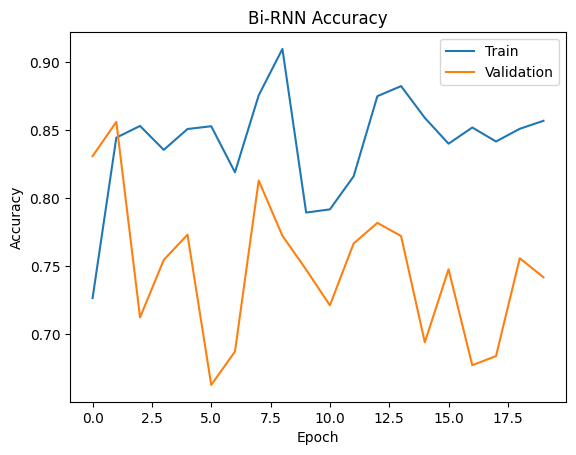

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Bi-RNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
sample = ["This movie was bad"]

seq = tokenizer.texts_to_sequences(sample)
pad = pad_sequences(seq, maxlen=100)

prediction = model.predict(pad)

if prediction[0][0] > 0.5:

    print("Positive 😊")
else:
    print("Negative 😠")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
Negative 😠


In [ ]:
print(prediction[0][0])

0.63081187
